In [ ]:
#Kaggle notebook to train the YOLOv11 model on the dataset

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.6 MB/s eta 0:00:0000:01


In [ ]:
from ultralytics import YOLO

# 1. Load your specific saved 'best' weights instead of 'yolo11s.pt'
model = YOLO("yolo11s.pt") 

# 2. Train again
results = model.train(
    data="/kaggle/input/datasets/rohanalexbimal/data-yaml-5/data.yaml",
    epochs=60,          # Set how many MORE epochs you want to run
    imgsz=640,
    batch=16,
    lr0=0.001,          # Tip: Use a lower learning rate for fine-tuning
    augment=True,
    degrees=10.0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/rohanalexbimal/data-yaml-5/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0

In [ ]:
# Load your best custom model
model = YOLO("runs/detect/train/weights/best.pt")

# Run inference
results = model.predict(
    source="/kaggle/input/datasets/rohanalexbimal/tooth-numbering/dataset/test/images/dd967cfa-20241204-112915388.jpg",
    conf=0.2,      # Ignore boxes with < 25% confidence
    iou=0.3,       # If two boxes overlap by > 45%, keep only the higher confidence one
    agnostic_nms=True # Set to True if you want to prevent overlaps between DIFFERENT classes
)

# Process results
for r in results:
    count = len(r.boxes.cls)
    print(r.boxes.cls)   # Detected tooth numbers
    print(r.boxes.conf)  # Confidence scores

print("Number of teeth", count)


image 1/1 /kaggle/input/datasets/rohanalexbimal/tooth-numbering/dataset/test/images/dd967cfa-20241204-112915388.jpg: 640x640 1 13, 1 23, 1 33, 1 43, 1 21, 1 41, 1 31, 1 11, 1 16, 1 26, 1 36, 1 46, 1 14, 1 34, 1 44, 1 24, 1 22, 1 32, 1 42, 1 12, 1 17, 1 27, 1 37, 1 47, 1 15, 1 25, 1 35, 1 45, 1 18, 1 28, 1 38, 1 48, 10.6ms
Speed: 1.7ms preprocess, 10.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
tensor([31.,  8., 22.,  1., 29., 23., 28., 11.,  9., 20.,  7., 10., 30., 12., 19., 25.,  4.,  5., 21., 27.,  2., 24., 15., 17., 26., 16., 13.,  3., 14.,  0.,  6., 18.], device='cuda:0')
tensor([0.8864, 0.8761, 0.8530, 0.8351, 0.8166, 0.8111, 0.7871, 0.7808, 0.7800, 0.7758, 0.7741, 0.7700, 0.7653, 0.7589, 0.7462, 0.7410, 0.7242, 0.7149, 0.7073, 0.6913, 0.6761, 0.6682, 0.6572, 0.6469, 0.5961, 0.5583, 0.5071, 0.4564, 0.4507, 0.4204, 0.3878, 0.2312], device='cuda:0')
Number of teeth 32


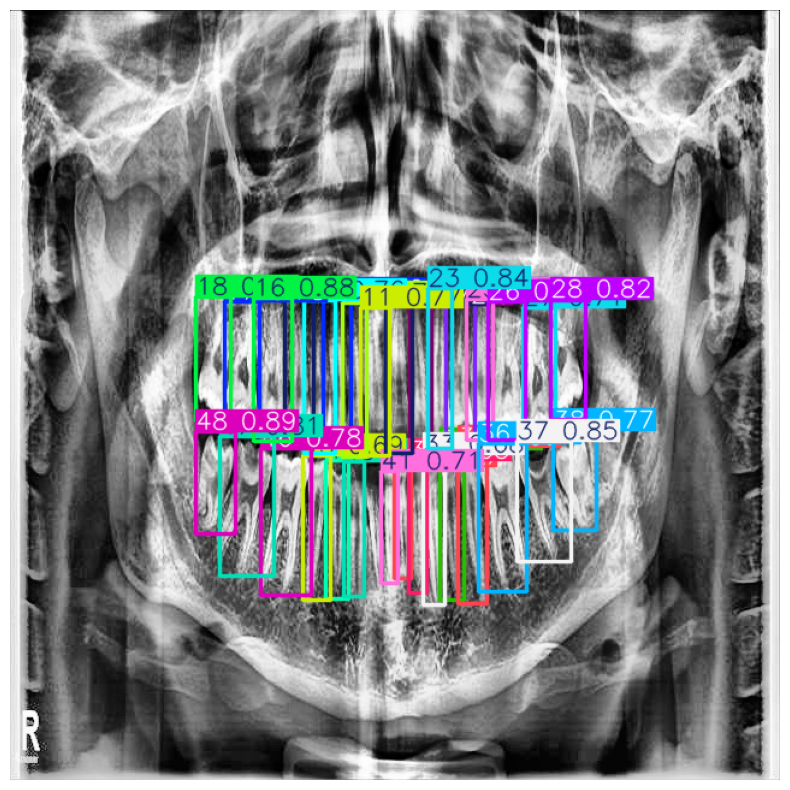

In [6]:
import matplotlib.pyplot as plt
import cv2

# The 'results' object contains the plotted image in the '.plot()' method
for r in results:
    im_array = r.plot()  # plot a BGR numpy array of predictions
    im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB) # Convert BGR to RGB
    
    plt.figure(figsize=(10, 10))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.show()